In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt


### Map view 

In [2]:
df = pd.read_csv(r'C:\Users\apaks\Desktop\Real Estate Project\artifacts\data\preprocessed-data\gurgaon_properties_with_lat_long.csv')

In [3]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,lat,lon
0,flat,sector 83,1.18,3,3,2,relatively new,1612.0,0,0,unfurnished,budget,high-rise,28.398567,76.964691
1,flat,sector 62,4.00,3,3,3,new,2353.0,1,0,semifurnished,budget,high-rise,28.413909,77.088594
2,flat,sector 85,1.10,2,2,3+,relatively new,1459.0,0,1,unfurnished,luxury,low-rise,28.404180,76.951343
3,flat,sector 91,0.89,2,2,3+,relatively new,1297.0,0,0,semifurnished,budget,medium-rise,28.401383,76.922532
4,flat,sector 7,0.48,3,2,1,new,889.0,0,0,unfurnished,budget,low-rise,28.464374,77.014294


In [4]:
df['price_per_sqft'] = round((df['price']/df['built_up_area'])*10000000, 2)

In [6]:
fig = px.scatter_map(data_frame = group_df, lat = 'lat', lon='lon', color='price_per_sqft', size = 'built_up_area', color_continuous_scale = px.colors.cyclical.IceFire, zoom = 10, map_style='open-street-map', text = group_df.index)

fig.show()

NameError: name 'group_df' is not defined

In [ ]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,lat,lon,price_per_sqft
0,flat,sector 83,1.18,3,3,2,relatively new,1612.0,0,0,unfurnished,budget,high-rise,28.398567,76.964691,7320.10
1,flat,sector 62,4.00,3,3,3,new,2353.0,1,0,semifurnished,budget,high-rise,28.413909,77.088594,16999.58
2,flat,sector 85,1.10,2,2,3+,relatively new,1459.0,0,1,unfurnished,luxury,low-rise,28.404180,76.951343,7539.41
3,flat,sector 91,0.89,2,2,3+,relatively new,1297.0,0,0,semifurnished,budget,medium-rise,28.401383,76.922532,6861.99
4,flat,sector 7,0.48,3,2,1,new,889.0,0,0,unfurnished,budget,low-rise,28.464374,77.014294,5399.33


In [ ]:
type = ['flat', 'house']

In [ ]:
df['property_type'].isin(type)

0       True
1       True
2       True
3       True
4       True
        ... 
3494    True
3495    True
3496    True
3497    True
3498    True
Name: property_type, Length: 3499, dtype: bool

In [ ]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,lat,lon,price_per_sqft
0,flat,sector 83,1.18,3,3,2,relatively new,1612.0,0,0,unfurnished,budget,high-rise,28.398567,76.964691,7320.10
1,flat,sector 62,4.00,3,3,3,new,2353.0,1,0,semifurnished,budget,high-rise,28.413909,77.088594,16999.58
2,flat,sector 85,1.10,2,2,3+,relatively new,1459.0,0,1,unfurnished,luxury,low-rise,28.404180,76.951343,7539.41
3,flat,sector 91,0.89,2,2,3+,relatively new,1297.0,0,0,semifurnished,budget,medium-rise,28.401383,76.922532,6861.99
4,flat,sector 7,0.48,3,2,1,new,889.0,0,0,unfurnished,budget,low-rise,28.464374,77.014294,5399.33


In [ ]:
df.shape

(3499, 16)

### Wordcloud 
- for features columns

In [7]:
df1 = pd.read_csv(r'C:\Users\apaks\Desktop\Real Estate Project\artifacts\data\preprocessed-data\gurgaon_properties_cleaned_v1.csv')

In [8]:
wordcloud_df = df1[['sector', 'features']]

In [9]:
wordcloud_df[wordcloud_df['sector'] == 'sector 1']

,sector,features
123,sector 1,"['Maintenance Staff', 'Water Storage', 'Separa..."
391,sector 1,"['Power Back-up', 'Intercom Facility', 'Lift(s..."
407,sector 1,NaN
412,sector 1,"['Piped-gas', 'Rain Water Harvesting']"
492,sector 1,NaN
520,sector 1,"['Security / Fire Alarm', 'Power Back-up', 'Fe..."
572,sector 1,"['Lift(s)', 'Maintenance Staff', 'Separate ent..."
626,sector 1,"['Lift(s)', 'Maintenance Staff', 'Park', 'Visi..."
642,sector 1,NaN
973,sector 1,NaN


In [ ]:
import ast
main = []
for row in wordcloud_df['features'].dropna().apply(ast.literal_eval):       # ast.literal_eval convert the list into python list
    main.extend(row)        # items of the row list are added to the main list
    

In [ ]:
feature_text = ' '.join(main)       # feature_text --> one string containing all the names of the features

In [ ]:
feature_text  

'Private Garden / Terrace Park Feng Shui / Vaastu Compliant Lift(s) Maintenance Staff Park Visitor Parking High Ceiling Height Maintenance Staff Swimming Pool Separate entry for servant room Fitness Centre / GYM Club house / Community Center Centrally Air Conditioned Water purifier Security / Fire Alarm Intercom Facility Lift(s) High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage No open drainage around Bank Attached Property Piped-gas Internet/wi-fi connectivity Visitor Parking Swimming Pool Park Security Personnel Natural Light Airy Rooms Low Density Society Waste Disposal Rain Water Harvesting Water softening plant Shopping Centre Fitness Centre / GYM Club house / Community Center Intercom Facility Lift(s) Maintenance Staff Lift(s) Maintenance Staff Water Storage Park Power Back-up Intercom Facility Lift(s) High Ceiling Height Maintenance Staff Water Storage Separate entry for servant room No open drainage around Swimming Pool Park Security Personnel Internet/

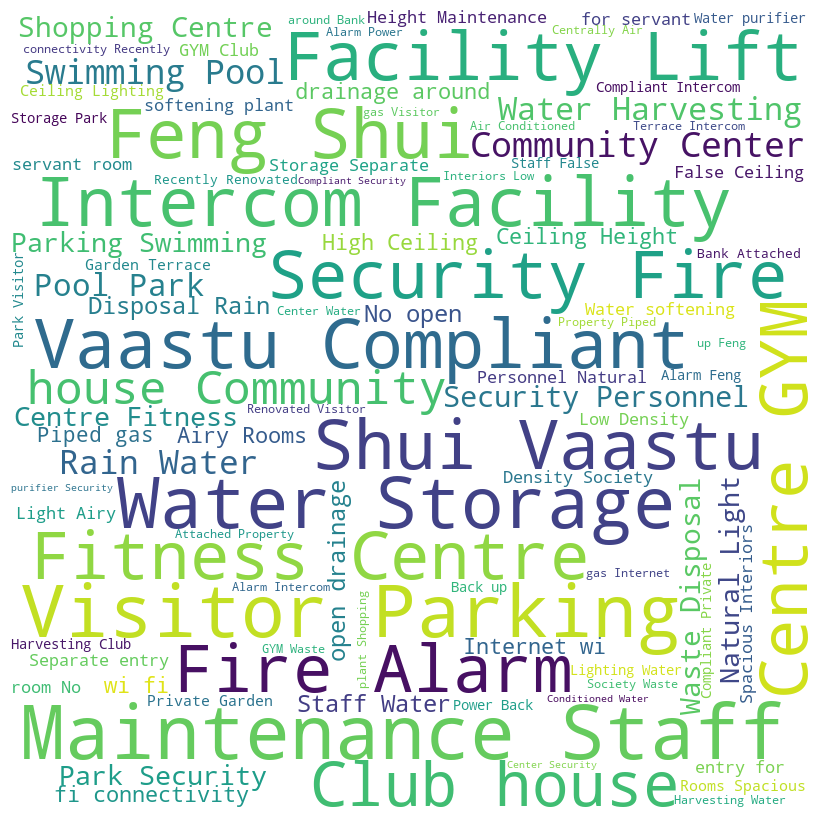

In [ ]:
from wordcloud import WordCloud

plt.rcParams['font.family'] = 'Arial'

wordcloud = WordCloud(width = 800, height = 800, background_color='white', stopwords= set(['s']), min_font_size=10).generate(feature_text)

plt.figure(figsize=(8,8), facecolor=None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout(pad = 0)
plt.show()

In [ ]:
# save feature text as pickle file
import pickle
import os

# os.makedirs('artifacts')

pickle.dump(feature_text, open(r'C:\Users\apaks\Desktop\Real Estate Project\artifacts\feature_text.pkl', 'wb'))

Pie Chart - Number of bedrooms

In [12]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,lat,lon,price_per_sqft
0,flat,sector 83,1.18,3,3,2,relatively new,1612.0,0,0,unfurnished,budget,high-rise,28.398567,76.964691,7320.10
1,flat,sector 62,4.00,3,3,3,new,2353.0,1,0,semifurnished,budget,high-rise,28.413909,77.088594,16999.58
2,flat,sector 85,1.10,2,2,3+,relatively new,1459.0,0,1,unfurnished,luxury,low-rise,28.404180,76.951343,7539.41
3,flat,sector 91,0.89,2,2,3+,relatively new,1297.0,0,0,semifurnished,budget,medium-rise,28.401383,76.922532,6861.99
4,flat,sector 7,0.48,3,2,1,new,889.0,0,0,unfurnished,budget,low-rise,28.464374,77.014294,5399.33


In [20]:
fig = px.pie(data_frame=df, names = 'bedRoom')
fig.update_layout(paper_bgcolor = 'black', plot_bgcolor = 'black', font = dict(color = 'white'), width = 500, height = 500)
fig.show()

Prices box plot for different number of rooms

In [22]:
df2 = df[df['bedRoom'] <= 4]

In [23]:
px.box(data_frame=df2, x = 'bedRoom', y = 'price')

dist plot of flats and houses distplot

In [24]:
import plotly.figure_factory as ff

In [25]:
flat_hist_data = df[df['property_type'] == 'flat']['price']
house_hist_data = df[df['property_type'] == 'house']['price']

In [ ]:
fig = ff.create_distplot(hist_data= [flat_hist_data, house_hist_data], group_labels=['Flats', 'House'])

fig.show()

In [ ]:
df['price_per_sqft']

Index(['property_type', 'sector', 'price', 'bedRoom', 'bathroom', 'balcony',
       'agePossession', 'built_up_area', 'servant room', 'store room',
       'furnishing_type', 'luxury_category', 'floor_category', 'lat', 'lon',
       'price_per_sqft'],
      dtype='object')

<Axes: xlabel='sector', ylabel='price_per_sqft'>

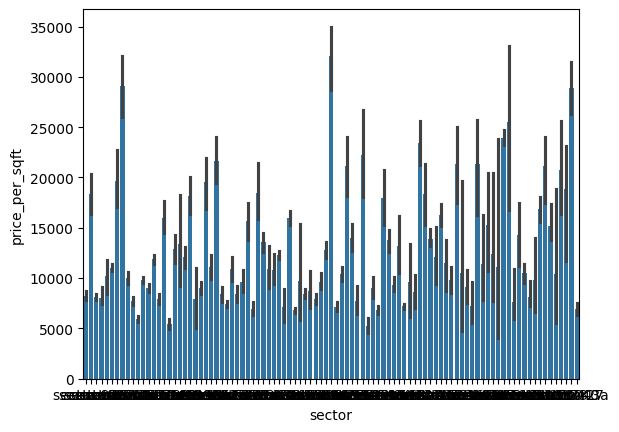

In [36]:
import seaborn as sns

sns.barplot(data= df, x= 'sector', y = 'price_per_sqft')

In [45]:
df.groupby(by='sector')['price_per_sqft'].mean().sort_values(ascending=False).head(5)

sector
sector 26    32098.728750
sector 25    29069.245278
sector 27    28889.755000
sector 45    25507.651429
sector 46    23952.196000
Name: price_per_sqft, dtype: float64